In [ ]:
# This code is part of QCMet.
# 
# (C) Copyright 2024 National Physical Laboratory and National Quantum Computing Centre 
# 
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
# 
#      http://www.apache.org/licenses/LICENSE-2.0
# 
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License

## Time to reset qubits

In [1]:
import qiskit
from qiskit import QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import itertools

import sys
import pathlib
import os
sys.path.insert(0, str(pathlib.Path(os.path.abspath('')).parent.parent.parent.resolve()))

# Disregard any warning on the following imports
from _helpers.circuit_submitter import CircuitSubmitter

In [2]:
device_name = "noisy_sim_with_shots"
submitter = CircuitSubmitter("time_to_reset_qubits", device_name)


In order to obtain the time taken to reset qubits, we run circuits composed of different numbers of gates and run them with different number of shots. Then, using the information provided by the vendor on the time taken to run the circuits, we can estimate the time to reset qubits.

The circuits are composed of repetitions of a circuit "C". Below, C is simply composed of 10 SX gates acting on the first qubit.


In [3]:
circuits = []
total_C_repetitions = 1000
repetition_spacing = 100
min_C_repetitions = 100
repetitions = [i for i in range(min_C_repetitions, total_C_repetitions, repetition_spacing)]
num_sx_gates_in_C = 10


max_num_shots = 50000
min_num_shots = 5000
num_shots_spacing = 5000
all_num_shots = range(min_num_shots, max_num_shots, num_shots_spacing)

obtained_t_tot = np.zeros((len(all_num_shots),len(repetitions)))
for i, shots in enumerate(all_num_shots):
    for j, repetition in enumerate(repetitions):
        circuit = qiskit.QuantumCircuit(QuantumRegister(2), ClassicalRegister(2))
        for _ in range(repetition):
            for _ in range(num_sx_gates_in_C):
                circuit.sx(0)
        circuit.measure(0, 0)

        #### The time taken to run a noisy simulation does not correspond to the actual time it would take to run the circuits with the timings set in the noise model.
        #### Thus, we cannot run the circuits and use the time taken to perform the simulation to obtain the metric. Instead, here we estimate the time it would take
        #### to run the circuit based on the real timings and a random overhead time.
        #### In practice, one would run the circuit and obtain "time_taken_to_run" from the vendor.


        # Times are in nanoseconds
        overhead_time = np.random.normal(0.1e9,0.005e9)
        time_to_execute_gates = 50 * repetition * num_sx_gates_in_C
        measurement_time = 1000
        reset_time = 1000
        time_taken_to_run = overhead_time + shots * (time_to_execute_gates + measurement_time + reset_time)
        obtained_t_tot[i,j] = time_taken_to_run

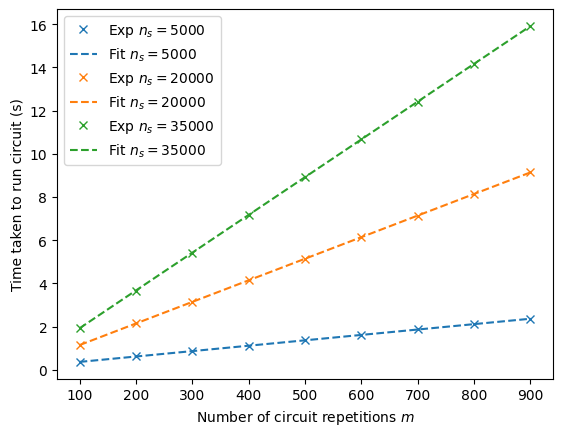

Estimated t_o = 100.6 +/- 1.2us
Estimated t_C = 500.0 +/- 0.1ns
Estimated t_m + t_reset = 1955.2 +/- 57.5ns

Using known t_m = 1000ns, we estimate time taken to reset qubits = 955.2 +/- 57.5ns


In [5]:
def fit_function(x, t_o,t_C, t_m_plus_reset):
    n_s = x[:,0]
    m = x[:,1]
    estimated_times = t_o + n_s*((m*t_C) + t_m_plus_reset)
    return estimated_times

x_data = np.array(list(itertools.product(all_num_shots, repetitions))) 
y_data = obtained_t_tot.flatten() 
popt,pcov, = curve_fit(fit_function,x_data,y_data,method="trf")
popt_std = np.sqrt(np.diag(pcov))


plt.figure()
for i, num_shots_index in enumerate([0,3,6]):
    fit_values = fit_function(x_data,*popt)
    fit_values = np.reshape(fit_values,(len(all_num_shots),len(repetitions)))
    plt.plot(repetitions, obtained_t_tot[num_shots_index]/1e9,label=fr"Exp $n_s = {all_num_shots[num_shots_index]}$",marker="x",linestyle="",c=f"C{i}")
    plt.plot(repetitions, fit_values[num_shots_index]/1e9,label=fr"Fit $n_s = {all_num_shots[num_shots_index]}$",marker="",linestyle="--",c=f"C{i}")
plt.legend()
plt.xlabel(f"Number of circuit repetitions $m$")
plt.ylabel(f"Time taken to run circuit (s)")
plt.show()

print(f"Estimated t_o = {popt[0]/1e6:.1f} +/- {popt_std[0]/1e6:.1f}us")
print(f"Estimated t_C = {popt[1]:.1f} +/- {popt_std[1]:.1f}ns")
print(f"Estimated t_m + t_reset = {popt[2]:.1f} +/- {popt_std[2]:.1f}ns")

max_measurement_time = 1000

print(f"\nUsing known t_m = {max_measurement_time}ns, we estimate time taken to reset qubits = {popt[2]-max_measurement_time:.1f} +/- {popt_std[2]:.1f}ns")